In [2]:
import pandas as pd

from google.colab import files

uploaded = files.upload()

Saving SCT_DA_4_Marketing_Campaign.csv to SCT_DA_4_Marketing_Campaign (1).csv


In [3]:
df = pd.read_csv("SCT_DA_4_Marketing_Campaign.csv")
df.head()

,Campaign_ID,Channel,Region,Campaign_Type,Ad_Spend,Impressions,Clicks,Leads,Conversions,Revenue
0,CMP0001,Google Ads,South,Awareness,4132.16,31833,1034,251,15,4002.80
1,CMP0002,YouTube Ads,East,Conversion,4910.96,48861,1409,316,12,3658.43
2,CMP0003,Instagram Ads,North,Consideration,2759.06,19505,572,109,6,1590.01
3,CMP0004,Facebook Ads,North,Consideration,2375.58,20786,1386,380,18,3420.91
4,CMP0005,Email,North,Awareness,1486.70,12565,1057,153,12,3327.03


In [4]:
df.shape

(505, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Campaign_ID    505 non-null    object 
 1   Channel        504 non-null    object 
 2   Region         504 non-null    object 
 3   Campaign_Type  504 non-null    object 
 4   Ad_Spend       504 non-null    float64
 5   Impressions    505 non-null    int64  
 6   Clicks         505 non-null    int64  
 7   Leads          505 non-null    int64  
 8   Conversions    505 non-null    int64  
 9   Revenue        504 non-null    float64
dtypes: float64(2), int64(4), object(4)
memory usage: 39.6+ KB


In [6]:
df.describe()

,Ad_Spend,Impressions,Clicks,Leads,Conversions,Revenue
count,504.000000,505.000000,505.000000,505.000000,505.000000,504.000000
mean,3171.420119,31535.053465,1730.746535,357.546535,18.582178,4965.605992
std,1053.585335,12250.864507,894.234171,209.873843,11.166031,3342.569703
min,877.070000,7497.000000,330.000000,56.000000,3.000000,711.290000
25%,2317.240000,21954.000000,1046.000000,202.000000,11.000000,2683.145000
50%,3185.880000,30417.000000,1541.000000,319.000000,16.000000,4163.120000
75%,3943.147500,39017.000000,2273.000000,468.000000,24.000000,6127.822500
max,6235.930000,74202.000000,5231.000000,1322.000000,73.000000,23537.290000


In [8]:
df.isnull().sum()

,0
Campaign_ID,0
Channel,1
Region,1
Campaign_Type,1
Ad_Spend,1
Impressions,0
Clicks,0
Leads,0
Conversions,0
Revenue,1


In [9]:
df.duplicated().sum()

np.int64(5)

In [10]:
df=df.drop_duplicates()
print("Duplicates remaining:",df.duplicated().sum())
print("Dataset shape:",df.shape)

Duplicates remaining: 0
Dataset shape: (500, 10)


In [11]:
df["Channel"] = df["Channel"].fillna(df["Channel"].mode()[0])
df["Region"] = df["Region"].fillna(df["Region"].mode()[0])
df["Campaign_Type"] = df["Campaign_Type"].fillna(df["Campaign_Type"].mode()[0])

df["Ad_Spend"] = df["Ad_Spend"].fillna(df["Ad_Spend"].median())
df["Revenue"] = df["Revenue"].fillna(df["Revenue"].median())

In [12]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Campaign_ID      0
Channel          0
Region           0
Campaign_Type    0
Ad_Spend         0
Impressions      0
Clicks           0
Leads            0
Conversions      0
Revenue          0
dtype: int64

Duplicate rows: 0


In [13]:
# Remove extra spaces and standardize text

df["Channel"] = df["Channel"].str.strip().str.title()
df["Region"] = df["Region"].str.strip().str.title()
df["Campaign_Type"] = df["Campaign_Type"].str.strip().str.title()

# Check the unique values
print("Channels:")
print(df["Channel"].unique())

print("\nRegions:")
print(df["Region"].unique())

print("\nCampaign Types:")
print(df["Campaign_Type"].unique())

Channels:
['Google Ads' 'Youtube Ads' 'Instagram Ads' 'Facebook Ads' 'Email'
 'Social Media']

Regions:
['South' 'East' 'North' 'West']

Campaign Types:
['Awareness' 'Conversion' 'Consideration']


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Campaign_ID    500 non-null    object 
 1   Channel        500 non-null    object 
 2   Region         500 non-null    object 
 3   Campaign_Type  500 non-null    object 
 4   Ad_Spend       500 non-null    float64
 5   Impressions    500 non-null    int64  
 6   Clicks         500 non-null    int64  
 7   Leads          500 non-null    int64  
 8   Conversions    500 non-null    int64  
 9   Revenue        500 non-null    float64
dtypes: float64(2), int64(4), object(4)
memory usage: 43.0+ KB


In [15]:
df.head()

,Campaign_ID,Channel,Region,Campaign_Type,Ad_Spend,Impressions,Clicks,Leads,Conversions,Revenue
0,CMP0001,Google Ads,South,Awareness,4132.16,31833,1034,251,15,4002.80
1,CMP0002,Youtube Ads,East,Conversion,4910.96,48861,1409,316,12,3658.43
2,CMP0003,Instagram Ads,North,Consideration,2759.06,19505,572,109,6,1590.01
3,CMP0004,Facebook Ads,North,Consideration,2375.58,20786,1386,380,18,3420.91
4,CMP0005,Email,North,Awareness,1486.70,12565,1057,153,12,3327.03


In [16]:
# Calculate funnel conversion rates

df["CTR"] = (df["Clicks"] / df["Impressions"]) * 100
df["Lead_Rate"] = (df["Leads"] / df["Clicks"]) * 100
df["Conversion_Rate"] = (df["Conversions"] / df["Leads"]) * 100

# Calculate ROI
df["ROI"] = ((df["Revenue"] - df["Ad_Spend"]) / df["Ad_Spend"]) * 100

# Calculate ROAS
df["ROAS"] = df["Revenue"] / df["Ad_Spend"]

df.head()

,Campaign_ID,Channel,Region,Campaign_Type,Ad_Spend,Impressions,Clicks,Leads,Conversions,Revenue,CTR,Lead_Rate,Conversion_Rate,ROI,ROAS
0,CMP0001,Google Ads,South,Awareness,4132.16,31833,1034,251,15,4002.80,3.248202,24.274662,5.976096,-3.130566,0.968694
1,CMP0002,Youtube Ads,East,Conversion,4910.96,48861,1409,316,12,3658.43,2.883690,22.427253,3.797468,-25.504789,0.744952
2,CMP0003,Instagram Ads,North,Consideration,2759.06,19505,572,109,6,1590.01,2.932581,19.055944,5.504587,-42.371315,0.576287
3,CMP0004,Facebook Ads,North,Consideration,2375.58,20786,1386,380,18,3420.91,6.667950,27.417027,4.736842,44.003149,1.440031
4,CMP0005,Email,North,Awareness,1486.70,12565,1057,153,12,3327.03,8.412256,14.474929,7.843137,123.786238,2.237862


In [17]:
channel_performance = df.groupby("Channel").agg({
    "Ad_Spend": "sum",
    "Revenue": "sum",
    "Impressions": "sum",
    "Clicks": "sum",
    "Leads": "sum",
    "Conversions": "sum"
}).reset_index()

channel_performance["ROI"] = (
    (channel_performance["Revenue"] - channel_performance["Ad_Spend"])
    / channel_performance["Ad_Spend"]
) * 100

channel_performance["ROAS"] = (
    channel_performance["Revenue"]
    / channel_performance["Ad_Spend"]
)

channel_performance.sort_values("ROI", ascending=False)

,Channel,Ad_Spend,Revenue,Impressions,Clicks,Leads,Conversions,ROI,ROAS
0,Email,195620.05,424222.12,1928328,100698,20017,1574,116.860245,2.168602
2,Google Ads,342916.78,706573.94,3508366,195112,39779,2337,106.048225,2.060482
3,Instagram Ads,204499.85,310699.36,2077523,108259,23151,1219,51.931339,1.519313
4,Social Media,205314.94,288753.68,2045095,113111,25094,1194,40.639390,1.406394
5,Youtube Ads,337348.69,459290.83,3310411,192536,38527,1658,36.147210,1.361472
1,Facebook Ads,300153.01,296695.80,2899814,154891,32327,1325,-1.151816,0.988482


In [18]:
channel_performance[
    ["Channel", "Ad_Spend", "Revenue", "Conversions", "ROI", "ROAS"]
].sort_values("ROI", ascending=False)

,Channel,Ad_Spend,Revenue,Conversions,ROI,ROAS
0,Email,195620.05,424222.12,1574,116.860245,2.168602
2,Google Ads,342916.78,706573.94,2337,106.048225,2.060482
3,Instagram Ads,204499.85,310699.36,1219,51.931339,1.519313
4,Social Media,205314.94,288753.68,1194,40.639390,1.406394
5,Youtube Ads,337348.69,459290.83,1658,36.147210,1.361472
1,Facebook Ads,300153.01,296695.80,1325,-1.151816,0.988482


In [19]:
# Overall marketing funnel

funnel = {
    "Impressions": df["Impressions"].sum(),
    "Clicks": df["Clicks"].sum(),
    "Leads": df["Leads"].sum(),
    "Conversions": df["Conversions"].sum()
}

print("Marketing Funnel")
print("----------------")
for stage, value in funnel.items():
    print(f"{stage}: {value:,}")

Marketing Funnel
----------------
Impressions: 15,769,537
Clicks: 864,607
Leads: 178,895
Conversions: 9,307


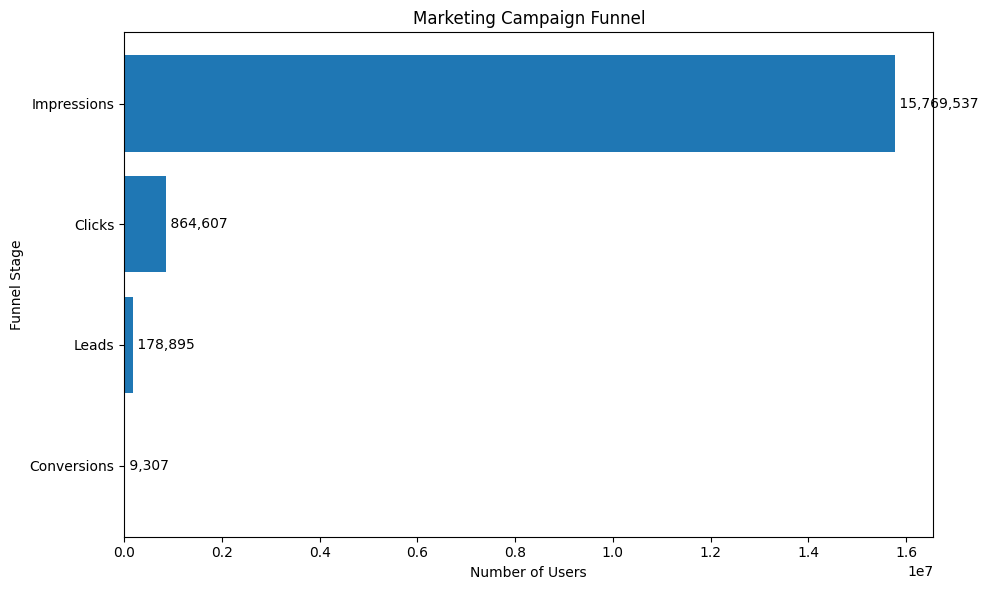

In [20]:
import matplotlib.pyplot as plt

stages = list(funnel.keys())
values = list(funnel.values())

plt.figure(figsize=(10, 6))

plt.barh(stages[::-1], values[::-1])

plt.xlabel("Number of Users")
plt.ylabel("Funnel Stage")
plt.title("Marketing Campaign Funnel")

for i, value in enumerate(values[::-1]):
    plt.text(value, i, f" {value:,}", va="center")

plt.tight_layout()
plt.show()

In [21]:
print("CTR:", round((df["Clicks"].sum() / df["Impressions"].sum()) * 100, 2), "%")

print("Lead Rate:", round((df["Leads"].sum() / df["Clicks"].sum()) * 100, 2), "%")

print("Conversion Rate:", round((df["Conversions"].sum() / df["Leads"].sum()) * 100, 2), "%")

CTR: 5.48 %
Lead Rate: 20.69 %
Conversion Rate: 5.2 %


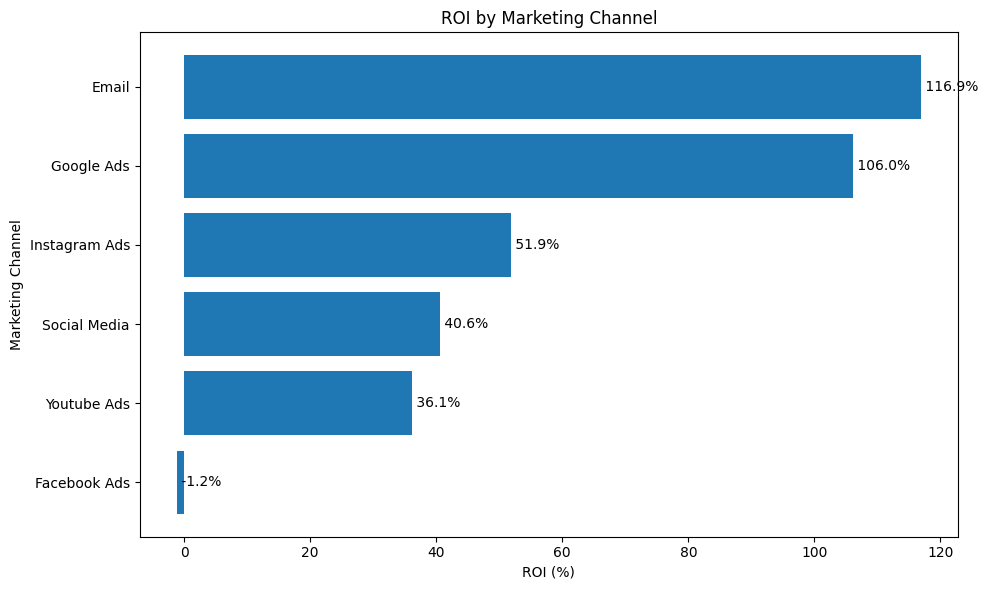

In [22]:
import matplotlib.pyplot as plt

roi_data = channel_performance.sort_values("ROI", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(roi_data["Channel"], roi_data["ROI"])

plt.xlabel("ROI (%)")
plt.ylabel("Marketing Channel")
plt.title("ROI by Marketing Channel")

for i, value in enumerate(roi_data["ROI"]):
    plt.text(value, i, f" {value:.1f}%", va="center")

plt.tight_layout()
plt.show()

In [23]:
roi_ranking = channel_performance[
    ["Channel", "Ad_Spend", "Revenue", "Conversions", "ROI", "ROAS"]
].sort_values("ROI", ascending=False)

roi_ranking

,Channel,Ad_Spend,Revenue,Conversions,ROI,ROAS
0,Email,195620.05,424222.12,1574,116.860245,2.168602
2,Google Ads,342916.78,706573.94,2337,106.048225,2.060482
3,Instagram Ads,204499.85,310699.36,1219,51.931339,1.519313
4,Social Media,205314.94,288753.68,1194,40.639390,1.406394
5,Youtube Ads,337348.69,459290.83,1658,36.147210,1.361472
1,Facebook Ads,300153.01,296695.80,1325,-1.151816,0.988482


In [24]:
channel_funnel = df.groupby("Channel").agg({
    "Impressions": "sum",
    "Clicks": "sum",
    "Leads": "sum",
    "Conversions": "sum"
}).reset_index()

channel_funnel

,Channel,Impressions,Clicks,Leads,Conversions
0,Email,1928328,100698,20017,1574
1,Facebook Ads,2899814,154891,32327,1325
2,Google Ads,3508366,195112,39779,2337
3,Instagram Ads,2077523,108259,23151,1219
4,Social Media,2045095,113111,25094,1194
5,Youtube Ads,3310411,192536,38527,1658


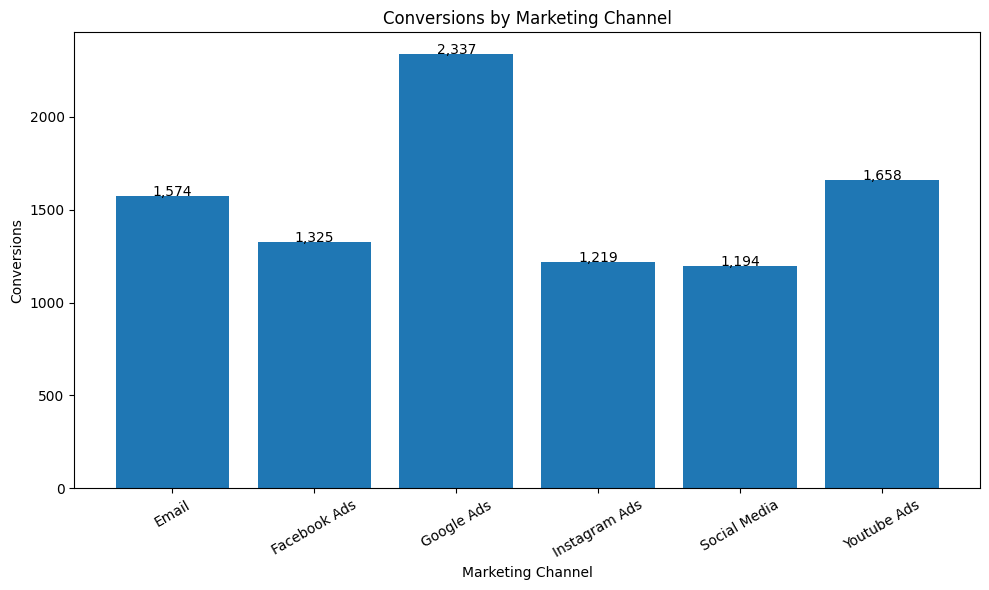

In [25]:
plt.figure(figsize=(10, 6))

plt.bar(
    channel_funnel["Channel"],
    channel_funnel["Conversions"]
)

plt.xlabel("Marketing Channel")
plt.ylabel("Conversions")
plt.title("Conversions by Marketing Channel")

plt.xticks(rotation=30)

for i, value in enumerate(channel_funnel["Conversions"]):
    plt.text(i, value, f"{value:,}", ha="center")

plt.tight_layout()
plt.show()

In [26]:
# Sort channels by ROI

roi_ranking = channel_performance.sort_values(
    "ROI", ascending=False
).reset_index(drop=True)

print("MARKETING CHANNEL ROI RANKING")
print("=============================")

for i, row in roi_ranking.iterrows():
    print(
        f"{i+1}. {row['Channel']} | "
        f"ROI: {row['ROI']:.2f}% | "
        f"ROAS: {row['ROAS']:.2f} | "
        f"Conversions: {int(row['Conversions']):,}"
    )

MARKETING CHANNEL ROI RANKING
1. Email | ROI: 116.86% | ROAS: 2.17 | Conversions: 1,574
2. Google Ads | ROI: 106.05% | ROAS: 2.06 | Conversions: 2,337
3. Instagram Ads | ROI: 51.93% | ROAS: 1.52 | Conversions: 1,219
4. Social Media | ROI: 40.64% | ROAS: 1.41 | Conversions: 1,194
5. Youtube Ads | ROI: 36.15% | ROAS: 1.36 | Conversions: 1,658
6. Facebook Ads | ROI: -1.15% | ROAS: 0.99 | Conversions: 1,325


In [28]:
best_channel = roi_ranking.iloc[0]
worst_channel = roi_ranking.iloc[-1]

print("\nBest ROI Channel:")
print(best_channel["Channel"], "-", round(best_channel["ROI"], 2), "%")

print("\nLowest ROI Channel:")
print(worst_channel["Channel"], "-", round(worst_channel["ROI"], 2), "%")


Best ROI Channel:
Email - 116.86 %

Lowest ROI Channel:
Facebook Ads - -1.15 %


In [29]:
df.to_csv("SCT_DA_4_Marketing_Campaign_Cleaned.csv", index=False)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


In [30]:
# Final channel performance summary

final_summary = df.groupby("Channel").agg({
    "Ad_Spend": "sum",
    "Revenue": "sum",
    "Impressions": "sum",
    "Clicks": "sum",
    "Leads": "sum",
    "Conversions": "sum"
}).reset_index()

final_summary["CTR (%)"] = (
    final_summary["Clicks"] / final_summary["Impressions"] * 100
)

final_summary["Conversion Rate (%)"] = (
    final_summary["Conversions"] / final_summary["Leads"] * 100
)

final_summary["ROI (%)"] = (
    (final_summary["Revenue"] - final_summary["Ad_Spend"])
    / final_summary["Ad_Spend"] * 100
)

final_summary["ROAS"] = (
    final_summary["Revenue"] / final_summary["Ad_Spend"]
)

final_summary = final_summary.sort_values(
    "ROI (%)", ascending=False
).round(2)

final_summary

,Channel,Ad_Spend,Revenue,Impressions,Clicks,Leads,Conversions,CTR (%),Conversion Rate (%),ROI (%),ROAS
0,Email,195620.05,424222.12,1928328,100698,20017,1574,5.22,7.86,116.86,2.17
2,Google Ads,342916.78,706573.94,3508366,195112,39779,2337,5.56,5.87,106.05,2.06
3,Instagram Ads,204499.85,310699.36,2077523,108259,23151,1219,5.21,5.27,51.93,1.52
4,Social Media,205314.94,288753.68,2045095,113111,25094,1194,5.53,4.76,40.64,1.41
5,Youtube Ads,337348.69,459290.83,3310411,192536,38527,1658,5.82,4.30,36.15,1.36
1,Facebook Ads,300153.01,296695.80,2899814,154891,32327,1325,5.34,4.10,-1.15,0.99


In [31]:
print("TOP 3 CHANNELS BY ROI")
print("=====================")

print(
    final_summary[
        ["Channel", "ROI (%)", "ROAS", "Conversions"]
    ].head(3).to_string(index=False)
)

print("\nBOTTOM 3 CHANNELS BY ROI")
print("=======================")

print(
    final_summary[
        ["Channel", "ROI (%)", "ROAS", "Conversions"]
    ].tail(3).to_string(index=False)
)

TOP 3 CHANNELS BY ROI
      Channel  ROI (%)  ROAS  Conversions
        Email   116.86  2.17         1574
   Google Ads   106.05  2.06         2337
Instagram Ads    51.93  1.52         1219

BOTTOM 3 CHANNELS BY ROI
     Channel  ROI (%)  ROAS  Conversions
Social Media    40.64  1.41         1194
 Youtube Ads    36.15  1.36         1658
Facebook Ads    -1.15  0.99         1325


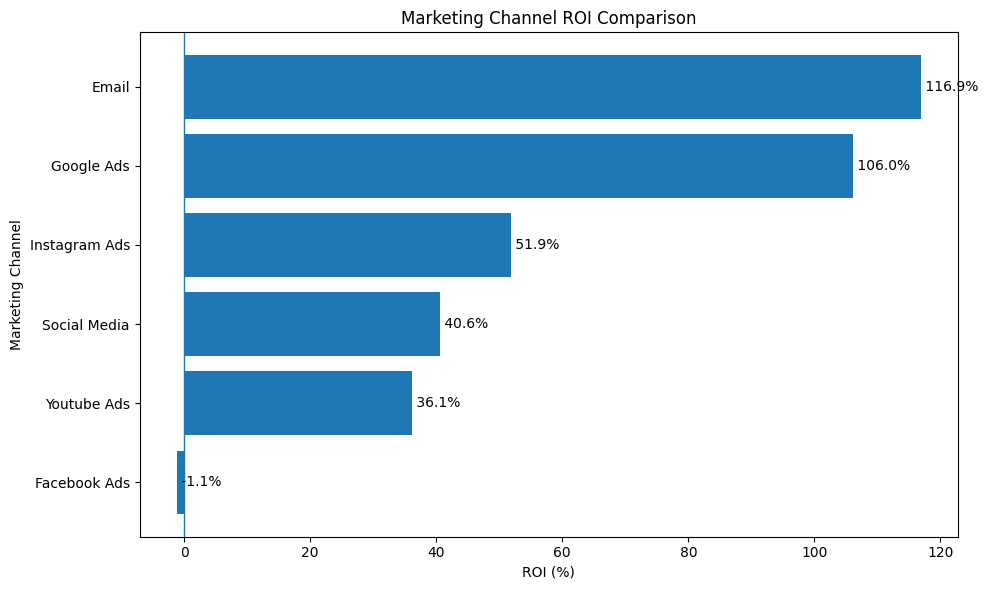

In [32]:
import matplotlib.pyplot as plt

roi_plot = final_summary.sort_values("ROI (%)")

plt.figure(figsize=(10, 6))

plt.barh(
    roi_plot["Channel"],
    roi_plot["ROI (%)"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("ROI (%)")
plt.ylabel("Marketing Channel")
plt.title("Marketing Channel ROI Comparison")

for i, value in enumerate(roi_plot["ROI (%)"]):
    plt.text(
        value,
        i,
        f" {value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

In [33]:
plt.savefig("SCT_DA_4_ROI_Chart.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [34]:
files.download("SCT_DA_4_ROI_Chart.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>